# Event-based Slip Estimation for Soft Terrains
Robots developed today struggle from movement in unpredictable and unseen terrains, mainly due to frame-based cameras' unfamiliarity with such environments, or absence of terrain data. But even when these challenges are addressed, low-light terrain can pose an even greater challenge: cameras depend heavily on light (absolute illumination), and the absence of light is, practically, the inefficiacy of conventional cameras. In our quest to solve visual odometry in low-light conditions and soft terrains conditions like the Moon, a new solution is much needed.

Enter event cameras. Also known as neuromorphic vision sensors (NVS), these cameras help capture data you need by detecting light changes and registering them as events. These events, described as (x, y, t), are data that help understand visual scenes in high bandwith, varying ranges, and power efficient, especially in power constrained places like space.

## The paper
This paper helps solve one part of the space visual odometry challenge: slip estimation. Slip estimation is a mathematical approach towards understanding the wheel slip of a vehicle through speed data. The core equation mentioned in the paper solves for slip through linear and angular speed:
$$
s = \left(1 - \frac{v_p}{r \, \omega}\right) \times 100\%
$$

where

$$
v_p = \frac{Z}{f \, m}
$$

**Parameters:**
- $s$: slip percentage  
- $v_p$: ground speed estimated from events (m/s)  
- $r$: wheel radius (m)  
- $\omega$: wheel angular speed (rad/s)  
- $Z$: camera height above ground (m)  
- $f$: camera focal length (pixels)  
- $m$: slope from $(x,t)$ line fit (seconds per pixel)  

In [2]:
def slip_pct(m, Z, f, r, omega):
	return (1 - ((Z / (f * m)) / (r * omega))) * 100

print(slip_pct(0.002, 0.1, 500, 0.1, 2.0))

50.0


### Event cameras in context: Space Exploration
Event cameras are known to be low-power, on-demand cameras that help in capturing visual data that is otherwise hard in low light and constrained environments. These kinds of environment are particulary abundant in a place like space. 

There are numerous engineering challenges that emerges when moving in terrains similar to the Moon or Mars. For example, on mars soft terrains produce challenges with regards to slippage which could lead to a space rover / robot getting trapped. Slippage is a main concern in space exploration. In 2010, NASA's Spirit, a space rover that landed on Mars and stayed there for over 5 years, got stuck because one reason: it didn't detect excessive slip early. 

> Slip, or in academic terms, slip ratio, is how much faster / slower is wheel than the ground speed.

In the paper, the focus is mainly on providing a framework for slip estimation in real time - fast, reliable, and low power. While Spirit rover did have slip moitoring, it wasn't as efficient and fast as the one proposed in this paper.

The approach presented by this paper is vision-based, meaning it utilizes visual data to estimate slip. While conventional cameras can be used to estimate slip, but due to the harsh low-light conditions that rovers deal with, the paper propose the usage of event cameras.

<img src="slip-estimation-config.png" alt="Slip Estimation Configuration" width="50%">


### Event capturing


In [2]:
!pip install tonic
!pip install torch


[notice] A new release of pip is available: 23.1.2 -> 25.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.1.2 -> 25.2
[notice] To update, run: pip install --upgrade pip


In [4]:
import tonic

dataset = tonic.datasets.NMNIST(save_to="../tutorials/data", train=False)

events, target = dataset[1000]
events


array([( 5, 14,   3380, 1), (13, 21,   4596, 0), ( 0, 12,   4793, 1), ...,
       (21, 13, 307906, 1), (20,  7, 308143, 1), (19,  5, 309314, 1)],
      dtype=[('x', '<i8'), ('y', '<i8'), ('t', '<i8'), ('p', '<i8')])

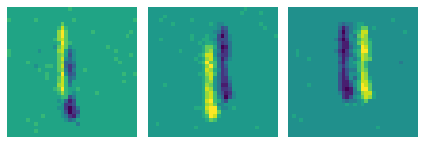

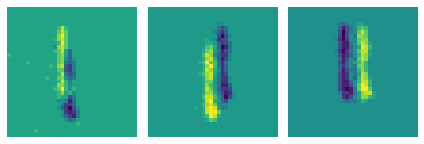

In [8]:
import tonic.transforms as transforms

sensor_size = tonic.datasets.NMNIST.sensor_size
frame_transform = transforms.ToFrame(sensor_size=sensor_size, n_time_bins=3)

frames = frame_transform(events)

%matplotlib inline
import matplotlib.pyplot as plt


def plot_frames(frames):
    fig, axes = plt.subplots(1, len(frames))
    for axis, frame in zip(axes, frames):
        axis.imshow(frame[1] - frame[0])
        axis.axis("off")
    plt.tight_layout()


plot_frames(frames)

denoise_transform = tonic.transforms.Denoise(filter_time=10000)

events_denoised = denoise_transform(events)
frames_denoised = frame_transform(events_denoised)

plot_frames(frames_denoised)

### Implementation Modules Overview

#### **1. EventReader**
- **Purpose**: Wraps **Metavision** / **DV SDK** / recorded data.
- **Output**: Yields batches of events:
  \[
  (x, y, t, p)
  \]
  where:
  - `x`, `y` → pixel coordinates
  - `t` → timestamp
  - `p` → polarity (+1 / -1)

---

#### **2. PolarityFilter**
- **Purpose**: Keep **negative polarity events only**.
- **Why**: The paper focuses on darker wheel traces caused by grousers digging into terrain.
- **Input**: \((x,y,t,p)\)
- **Output**: Filtered events where \(p = -1\).

---

#### **3. BinaryAccumulator**
- **Purpose**: Bin events into a **2D (x,t) image** over a **sliding Δt window**.
- **Why**: Converts sparse event streams into a structured representation suitable for line detection.
- **Output**: Binary matrix representing event activity over time.

---

#### **4. YangDenoiser**
- **Purpose**: Implements the **Yang filter** described in the paper.
- **Steps**:
  1. Compute **ψ** = local event density within an \(L \times L \times \Delta t\) cube.
  2. Optionally compute **R** = flicker score using event polarity consistency.
  3. Threshold ψ against Ψ to discard background noise.
- **Output**: Cleaned **binary event map**.

---

#### **5. HoughLines**
- **Purpose**: Apply **Hough Transform** to detect dominant line(s) in the (x,t) image.
- **Output**:
  - **Slope \(m\)** of detected line(s).
  - \(m\) corresponds to the apparent speed of wheel traces in the event data.

---

#### **6. Kinematics**
- **Purpose**: Convert detected slopes into slip estimates.
- **Equations**:
  - Terrain velocity:
    \[
    v_p = \frac{Y}{m}
    \]
    where:
    - \(Y\) = camera scale factor (calibration constant from \(Z, f\)).
  - Slip ratio:
    \[
    s_p = \left(1 - \frac{v_p}{r \cdot \omega}\right) \times 100\%
    \]
    where:
    - \(r\) = wheel radius,
    - \(\omega\) = wheel angular velocity,
    - \(Z\) = camera height,
    - \(f\) = focal length.

---

#### **7. Evaluator**
- **Purpose**: Quantify algorithm performance.
- **Metrics**:
  - **MAE** (Mean Absolute Error)
  - **SD** (Standard Deviation)
- **Comparison**:
  - Evaluates estimated slip \(s_p\) against ground truth from **carriage velocity**.
- **Usage**:
  - Matches methodology in the paper’s **Tables** and **Figures**.
